# GSB-S545 Midterm Modeling Project
**Task:** Binary classification — predict `accepted_offer` (0 = did not accept, 1 = accepted)  
**Dataset:** Bank marketing outreach data (~7,700 training rows, 22 features)  
**Primary Metric:** F1-score (class imbalance expected ~11% accept rate)

---

## Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
                             balanced_accuracy_score, classification_report, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42

## Section 1: Exploratory Data Analysis

The goal here is to understand the data structure, identify imbalance, and surface patterns that should inform preprocessing and modeling decisions. Plots and summaries below focus on what actually changed my approach — not exhaustive coverage of every column.

### 1.1 Load Data & Initial Inspection

In [4]:
train = pd.read_csv(r"C:\Users\ldcal\OneDrive\Desktop\Cal Poly Courses\Spring\GSB-S545\Advanced_ML_Work\Git_Code\Midterm Take Home\Data\midterm_train.csv")
test  = pd.read_csv(r"C:\Users\ldcal\OneDrive\Desktop\Cal Poly Courses\Spring\GSB-S545\Advanced_ML_Work\Git_Code\Midterm Take Home\Data\midterm_test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
train.head(3)

Train shape: (32950, 23)
Test shape:  (8238, 22)


,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,contact_time_minutes,contact_attempt_count,days_since_prior_contact,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,286,1,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,178,2,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,345,1,999,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0


In [5]:
print("--- Data Types & Non-Null Counts ---")
train.info()

--- Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         32950 non-null  int64  
 1   customer_age               32950 non-null  int64  
 2   occupation_type            32950 non-null  str    
 3   relationship_status        32950 non-null  str    
 4   education_background       32950 non-null  str    
 5   has_credit_issue           32950 non-null  str    
 6   mortgage_status            32950 non-null  str    
 7   personal_loan_status       32950 non-null  str    
 8   last_contact_month         32950 non-null  str    
 9   day_of_week                32950 non-null  str    
 10  contact_time_minutes       32950 non-null  int64  
 11  contact_attempt_count      32950 non-null  int64  
 12  days_since_prior_contact   32950 non-null  int64  
 13  prior_contact_count 

In [6]:
print("--- Missing Values ---")
missing = train.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values in raw data.")

--- Missing Values ---
No missing values in raw data.


In [7]:
# Numeric summary
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,32950.0,20612.919423,11872.660725,0.000,10373.250,20610.500,30858.750,41187.000
customer_age,32950.0,40.016813,10.421766,17.000,32.000,38.000,47.000,98.000
contact_time_minutes,32950.0,257.355387,256.687433,0.000,102.000,180.000,318.000,4918.000
contact_attempt_count,32950.0,2.556601,2.751165,1.000,1.000,2.000,3.000,56.000
days_since_prior_contact,32950.0,961.748892,188.697125,0.000,999.000,999.000,999.000,999.000
prior_contact_count,32950.0,0.173445,0.496422,0.000,0.000,0.000,0.000,7.000
economic_activity_change,32950.0,0.077132,1.572468,-3.400,-1.800,1.100,1.400,1.400
consumer_price_index,32950.0,93.574951,0.579559,92.201,93.075,93.749,93.994,94.767
consumer_confidence_index,32950.0,-40.508273,4.628221,-50.800,-42.700,-41.800,-36.400,-26.900
reference_interest_rate,32950.0,3.614729,1.737144,0.634,1.344,4.857,4.961,5.045


### 1.2 Target Distribution — Class Imbalance

Checking the accept rate first because severe imbalance directly affects which metrics and model settings matter most.

Accept rate: 11.27%
accepted_offer
0    29235
1     3715
Name: count, dtype: int64


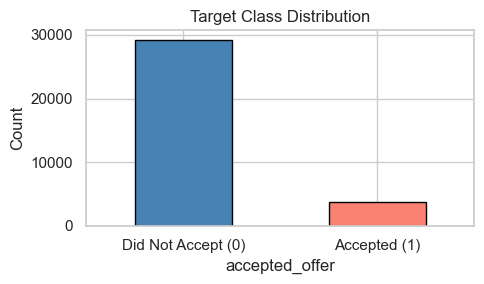

scale_pos_weight (neg/pos): 7.87


In [8]:
accept_rate = train['accepted_offer'].mean()
print(f"Accept rate: {accept_rate:.2%}")
print(train['accepted_offer'].value_counts())

fig, ax = plt.subplots(figsize=(5, 3))
train['accepted_offer'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='black')
ax.set_xticklabels(['Did Not Accept (0)', 'Accepted (1)'], rotation=0)
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Imbalance ratio — used to set scale_pos_weight in XGBoost
n_neg = (train['accepted_offer'] == 0).sum()
n_pos = (train['accepted_offer'] == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight (neg/pos): {scale_pos_weight:.2f}")

### 1.3 Sentinel Value: `days_since_prior_contact = 999`

999 is a placeholder meaning "never contacted before" — it is not a real duration. Keeping it as a numeric value would distort any distance-based or scaled feature. This confirms we need a binary flag.

In [9]:
print("Value counts for days_since_prior_contact (top 5):")
print(train['days_since_prior_contact'].value_counts().head())
print(f"\nRows with 999: {(train['days_since_prior_contact'] == 999).sum()} "
      f"({(train['days_since_prior_contact'] == 999).mean():.1%} of training set)")

Value counts for days_since_prior_contact (top 5):
days_since_prior_contact
999    31714
3        371
6        330
4        101
7         50
Name: count, dtype: int64

Rows with 999: 31714 (96.2% of training set)


### 1.4 Categorical Features — Rare Labels & 'Unknown' Values

`has_credit_issue` and `education_background` both contain `'unknown'` values. These are treated as a separate category rather than imputed, since 'unknown' may carry signal (e.g., customers who don't disclose credit history may behave differently).

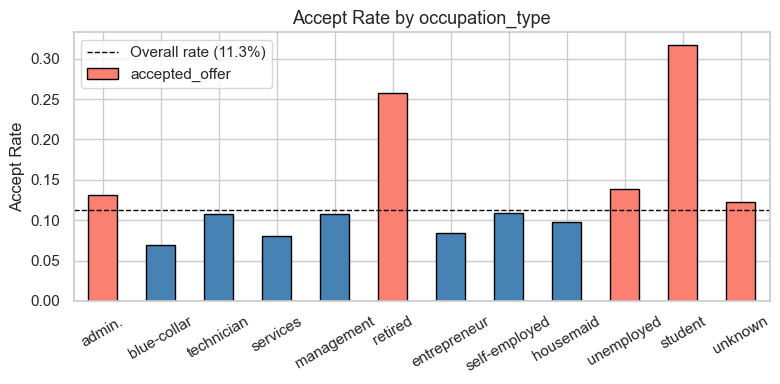

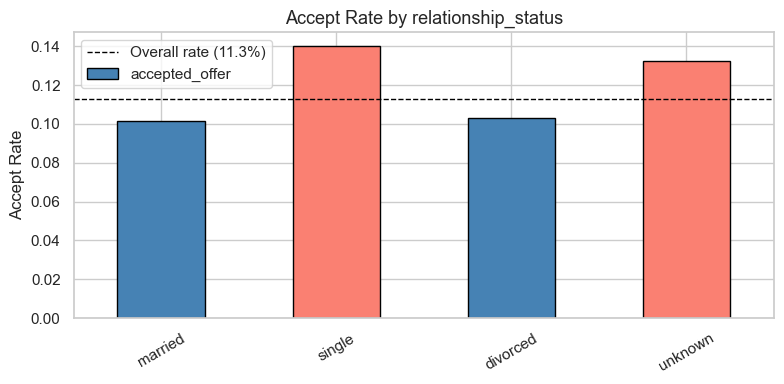

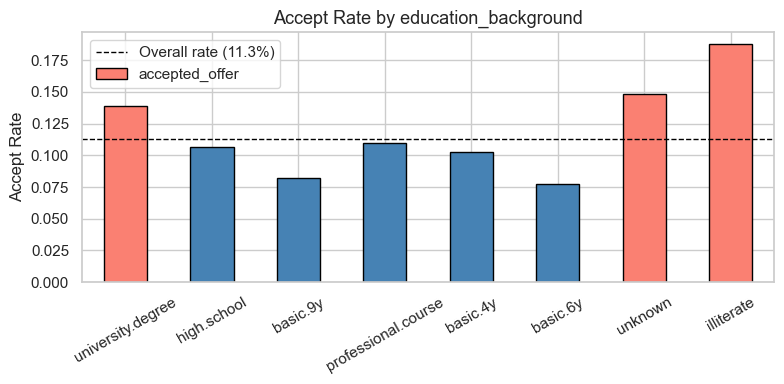

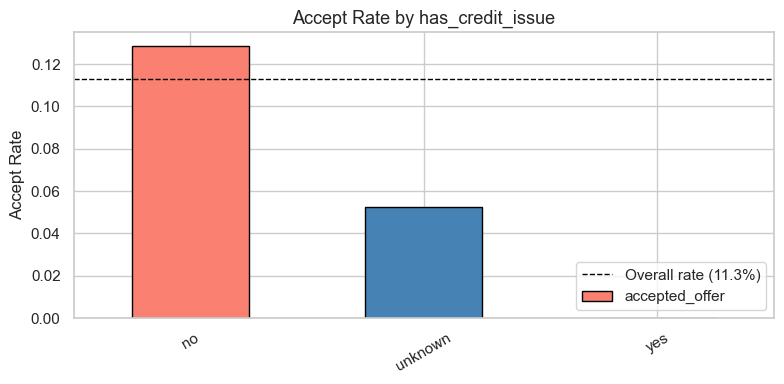

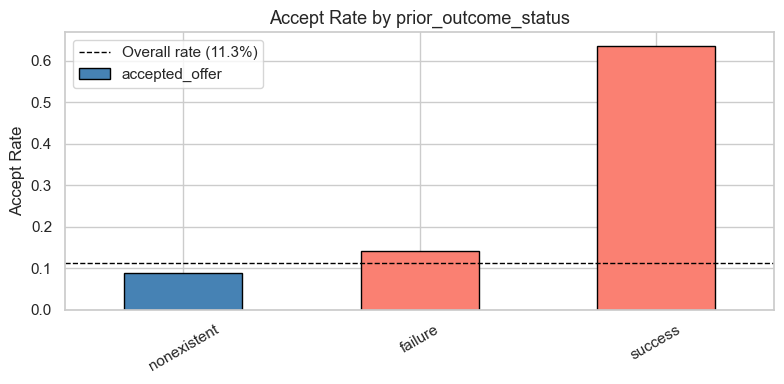

In [19]:
cat_cols = ['occupation_type', 'relationship_status', 'education_background',
            'has_credit_issue', 'prior_outcome_status']

for col in cat_cols:
    order = train[col].value_counts().index
    accept_by_cat = train.groupby(col)['accepted_offer'].mean().reindex(order)
    colors = ['salmon' if v > accept_rate else 'steelblue' for v in accept_by_cat]

    fig, ax = plt.subplots(figsize=(8, 4))
    accept_by_cat.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
    ax.axhline(accept_rate, color='black', linestyle='--', linewidth=1,
               label=f'Overall rate ({accept_rate:.1%})')
    ax.set_title(f'Accept Rate by {col}', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Accept Rate')
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [11]:
# Check 'unknown' frequency in key columns
for col in ['has_credit_issue', 'education_background', 'occupation_type']:
    unknowns = (train[col] == 'unknown').sum()
    print(f"{col}: {unknowns} unknowns ({unknowns/len(train):.1%})")

has_credit_issue: 6858 unknowns (20.8%)
education_background: 1406 unknowns (4.3%)
occupation_type: 262 unknowns (0.8%)


### 1.5 Economic Indicator Correlations

The economic macro features (`consumer_price_index`, `reference_interest_rate`, `employment_level_index`, etc.) are externally sourced and likely to be highly correlated with each other. High multicollinearity won't hurt tree models but is worth confirming.

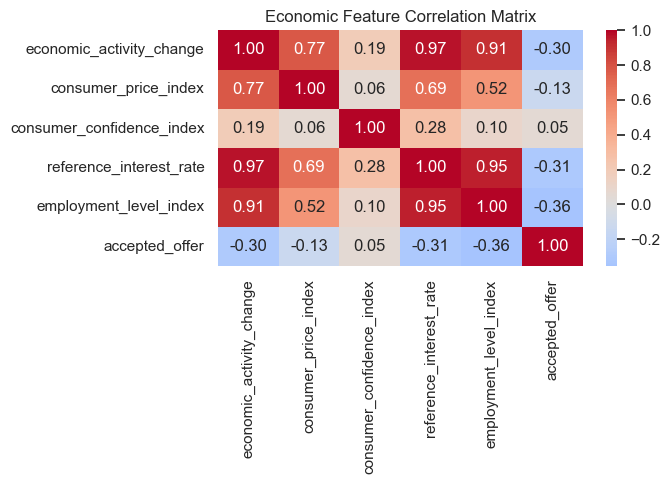

In [12]:
econ_cols = ['economic_activity_change', 'consumer_price_index', 'consumer_confidence_index',
             'reference_interest_rate', 'employment_level_index']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(train[econ_cols + ['accepted_offer']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('Economic Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### 1.6 Key Numeric Distributions vs. Target

Checking distributions of the most predictive numeric features split by `accepted_offer` to identify separation.

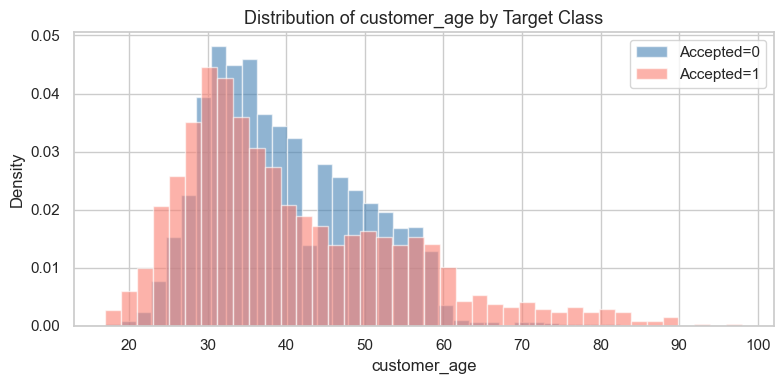

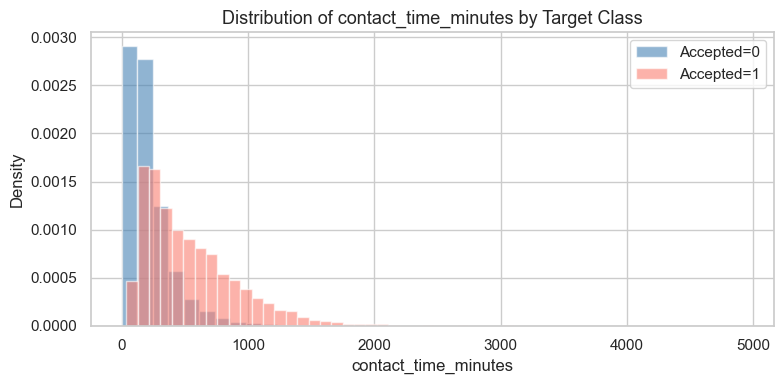

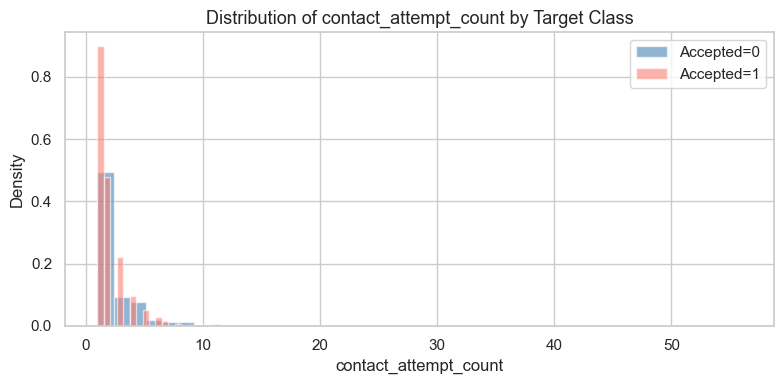

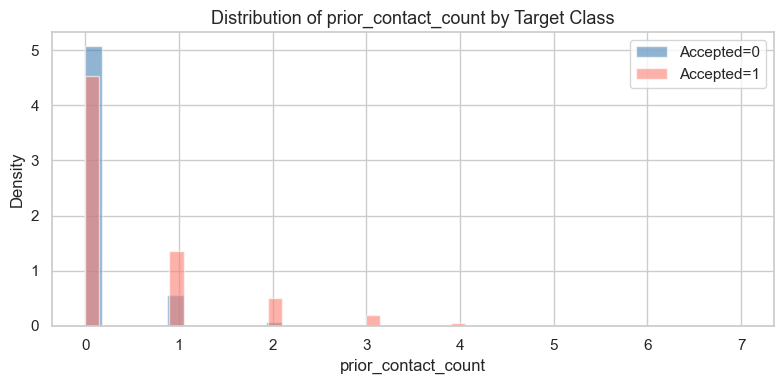

In [20]:
num_cols = ['customer_age', 'contact_time_minutes', 'contact_attempt_count', 'prior_contact_count']

for col in num_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    for label, color in [(0, 'steelblue'), (1, 'salmon')]:
        subset = train[train['accepted_offer'] == label][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label=f'Accepted={label}', density=True)
    ax.set_title(f'Distribution of {col} by Target Class', fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    plt.show()

**EDA Takeaways that shaped modeling:**
- ~11% accept rate — significant imbalance; use `scale_pos_weight` for XGBoost, `class_weight='balanced'` for sklearn models, and optimize F1 not accuracy.
- `days_since_prior_contact = 999` (~80%+ of rows) is a sentinel — will be flagged as `was_previously_contacted` and the raw value capped/treated separately.
- `prior_outcome_status = 'success'` shows a large lift in accept rate — this column will be high-importance.
- Economic indicators are highly correlated; tree models handle this natively so no dimensionality reduction applied, but worth monitoring feature importance.
- `'unknown'` values in `has_credit_issue` and `education_background` are kept as a separate category — they may carry information about who is less forthcoming with financial details.

---

## Section 2: Data Preparation

Preprocessing pipeline applied consistently to train and test. Feature engineering derived from EDA insights above.

### 2.1 Feature Engineering

In [14]:
def engineer_features(df):
    df = df.copy()

    # 999 = never contacted before; flag separately before capping
    df['was_previously_contacted'] = (df['days_since_prior_contact'] != 999).astype(int)
    df['days_since_prior_contact'] = df['days_since_prior_contact'].replace(999, np.nan)

    # Prior campaign success as a clean binary
    df['prior_success_flag'] = (df['prior_outcome_status'] == 'success').astype(int)

    # Log-transform right-skewed contact duration
    df['log_contact_time'] = np.log1p(df['contact_time_minutes'])

    # Cyclical encoding for month and weekday to preserve circular ordering
    month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
                 'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
    dow_map   = {'mon':1,'tue':2,'wed':3,'thu':4,'fri':5}
    df['month_num'] = df['last_contact_month'].str.lower().map(month_map)
    df['dow_num']   = df['day_of_week'].str.lower().map(dow_map)
    df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
    df['dow_sin']   = np.sin(2 * np.pi * df['dow_num'] / 5)
    df['dow_cos']   = np.cos(2 * np.pi * df['dow_num'] / 5)

    return df

train = engineer_features(train)
test  = engineer_features(test)

print("Feature engineering complete.")
print(f"Train shape after engineering: {train.shape}")

Feature engineering complete.
Train shape after engineering: (32950, 32)


### 2.2 Define Feature Sets & Split

Drop `id` and the raw cyclical columns that were replaced by sin/cos encodings.

In [15]:
DROP_COLS = ['id', 'last_contact_month', 'day_of_week', 'month_num', 'dow_num']
TARGET = 'accepted_offer'

X = train.drop(columns=DROP_COLS + [TARGET])
y = train[TARGET]
X_test_final = test.drop(columns=[c for c in DROP_COLS if c in test.columns])

# Numeric features — includes engineered ones; exclude the original raw cyclical columns
numeric_features = [
    'customer_age', 'contact_time_minutes', 'log_contact_time',
    'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count',
    'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index',
    'reference_interest_rate', 'employment_level_index',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos'
]

# Binary features — already 0/1, no scaling needed
binary_features = [
    'is_repeat_customer', 'recent_contact_flag',
    'was_previously_contacted', 'prior_success_flag'
]

# Categorical features — one-hot encoded
categorical_features = [
    'occupation_type', 'relationship_status', 'education_background',
    'has_credit_issue', 'mortgage_status', 'personal_loan_status',
    'prior_outcome_status'
]

all_features = numeric_features + binary_features + categorical_features
print(f"Total features going into pipeline: {len(all_features)}")

# Confirm no features are missing from X
missing_from_X = [f for f in all_features if f not in X.columns]
print(f"Missing from X: {missing_from_X}")

Total features going into pipeline: 26
Missing from X: []


In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X[all_features], y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}")
print(f"Train accept rate: {y_train.mean():.2%}  |  Val accept rate: {y_val.mean():.2%}")

X_train: (26360, 26)  |  X_val: (6590, 26)
Train accept rate: 11.27%  |  Val accept rate: 11.27%


### 2.3 Preprocessing Pipeline

- Numeric: median imputation (handles the NaNs from the 999 replacement) + MinMax scaling
- Binary: passthrough — already 0/1 integers
- Categorical: most-frequent imputation + one-hot encoding (`handle_unknown='ignore'` so unseen test labels don't break inference)

In [17]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num',    numeric_transformer,    numeric_features),
    ('bin',    'passthrough',          binary_features),
    ('cat',    categorical_transformer, categorical_features)
])

# Fit on train only — transform val and test separately to prevent leakage
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test_final[all_features])

print(f"Processed train shape: {X_train_proc.shape}")
print(f"Processed val shape:   {X_val_proc.shape}")
print(f"Processed test shape:  {X_test_proc.shape}")

Processed train shape: (26360, 48)
Processed val shape:   (6590, 48)
Processed test shape:  (8238, 48)


In [18]:
# Cross-validation setup reused throughout modeling sections
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Imbalance ratio — passed to XGBoost scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print("Preprocessing pipeline ready. Proceeding to baseline models.")

scale_pos_weight: 7.87
Preprocessing pipeline ready. Proceeding to baseline models.
